# Utvidelse 02 — Skill mellom effektkapasitet (GW) og energikapasitet (GWh/TWh)

Hovednotebooken behandler batteriparken som rent **energilager**: `E_installert = P_residual × 24 × d / utnyttbar`.

I virkeligheten har et batterisystem **to** kapasiteter:

- **Effektkapasitet** $P_{bess}$ [GW]: hvor mye man kan trekke til/fra på et øyeblikk.
- **Energikapasitet** $E_{bess}$ [GWh]: hvor mye energi som ligger i bankene.

Forholdet $E/P$ kalles ofte **varighet** (duration) og uttrykkes i timer. Et 4-timers BESS har $E = 4 \times P$. For Dunkelflaute trengs varighet i størrelsesorden **flere døgn**, dvs. $E/P$ på 50–250 timer — langt over dagens kommersielle norm på 2–8 timer.

Denne notebooken regner kost separat for effekt-delen (omformere, transformatorer, nettilknytning) og energi-delen (celler, racks, brann/HVAC).


## Oslo-år som felles målestokk

I alle utvidelsene bruker vi samme norske normalisering: **Oslo ≈ 1 GW kontinuerlig ≈ 8,76 TWh per år**. Det gjør GW- og TWh-tall lettere å lese uten å blande effekt med energi.


In [ ]:
HOURS_PER_YEAR = 8760

anchors = {
    "Norsk husholdning": {"energy_kwh_per_year": 14_700, "source": "SSB 2024"},
    "Bergen kommune": {"energy_twh_per_year": 3.4898, "source": "SSB tabell 14490, 2024"},
    "Oslo kommune": {"energy_twh_per_year": 8.7589, "source": "SSB tabell 14490, 2024"},
    "Statkraft Norge": {"energy_twh_per_year": 51.2, "source": "Statkraft 2025"},
    "Norge forbruk inkl. tap": {"energy_twh_per_year": 139.2, "source": "Statnett 2025"},
    "Norge produksjon": {"energy_twh_per_year": 162.0, "source": "Statnett 2025"},
}


def twh_to_average_gw(twh_per_year):
    return twh_per_year / (HOURS_PER_YEAR / 1000)


def gw_to_twh_per_year(gw):
    return gw * HOURS_PER_YEAR / 1000


def twh_to_oslo_years(twh):
    return twh / anchors["Oslo kommune"]["energy_twh_per_year"]


def oslo_average_gw():
    return twh_to_average_gw(anchors["Oslo kommune"]["energy_twh_per_year"])


def describe_energy(twh):
    return {
        "TWh": twh,
        "Oslo-år": twh_to_oslo_years(twh),
        "Bergen-år": twh / anchors["Bergen kommune"]["energy_twh_per_year"],
        "Statkraft Norge-år": twh / anchors["Statkraft Norge"]["energy_twh_per_year"],
        "Norge-forbruksår": twh / anchors["Norge forbruk inkl. tap"]["energy_twh_per_year"],
        "Gjennomsnittlig GW i ett år": twh_to_average_gw(twh),
    }


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults = json.loads(next(p for p in candidates if p.exists()).read_text())["defaults"]
defaults


{'eu_annual_electricity_twh': 2790.0,
 'average_load_gw': 318.0,
 'residual_gap_gw': 250.0,
 'event_days': 10.0,
 'usable_fraction': 0.8,
 'stationary_pack_cost_usd_per_kwh': 70.0,
 'turnkey_bess_cost_usd_per_kwh': 117.0,
 'lfp_share': 0.75,
 'sodium_ion_share': 0.15,
 'other_long_duration_share': 0.1,
 'lfp_lithium_intensity_kg_per_kwh': 0.09,
 'global_lithium_production_tonnes_2025': 290000.0,
 'global_battery_cell_manufacturing_capacity_twh_2024': 3.0,
 'committed_global_cell_capacity_twh_2030': 6.5,
 'eu_bess_additions_gwh_2025': 27.1}

## Splittet kostmodell

Vi deler turnkey-kost i to komponenter, basert på offentlig BNEF-strukturering for stasjonær lagring:

- **Power-relaterte kostnader** $c_P$ [USD/kW]: PCS, MV-trafo, switchgear, EPC, nettilknytning, kontrollsystem.
- **Energi-relaterte kostnader** $c_E$ [USD/kWh]: celler, moduler, racks, BMS, brann/HVAC, container.

Total kost: $C = c_P \times P + c_E \times E$.

Standardverdiene under er pedagogiske og holdes lett endringsbare.


In [2]:
c_power_usd_per_kw = 250.0   # PCS + EPC + nett
c_energy_usd_per_kwh = 90.0   # celler + rack + BMS

def split_cost(power_gw: float, duration_h: float):
    energy_gwh = power_gw * duration_h
    p_cost = c_power_usd_per_kw * power_gw * 1e6   # GW -> kW
    e_cost = c_energy_usd_per_kwh * energy_gwh * 1e6
    total = p_cost + e_cost
    return {
        "power_GW": power_gw,
        "duration_h": duration_h,
        "energy_GWh": energy_gwh,
        "energy_TWh": energy_gwh / 1000,
        "Oslo-år": twh_to_oslo_years(energy_gwh / 1000),
        "power_cost_bn_USD": p_cost / 1e9,
        "energy_cost_bn_USD": e_cost / 1e9,
        "total_cost_bn_USD": total / 1e9,
        "blended_USD_per_kWh": total / (energy_gwh * 1e6),
    }

split_cost(power_gw=1.0, duration_h=4)


{'power_GW': 1.0,
 'duration_h': 4,
 'energy_GWh': 4.0,
 'power_cost_bn_USD': 0.25,
 'energy_cost_bn_USD': 0.36,
 'total_cost_bn_USD': 0.61,
 'blended_USD_per_kWh': 152.5}

## Hva skjer når varigheten øker fra 4 t til Dunkelflaute-skala?


In [3]:
durations = [2, 4, 8, 24, 72, 240]  # timer
rows = [split_cost(power_gw=250, duration_h=d) for d in durations]
df = pd.DataFrame(rows)
df


,power_GW,duration_h,energy_GWh,power_cost_bn_USD,energy_cost_bn_USD,total_cost_bn_USD,blended_USD_per_kWh
0,250,2,500,62.5,45.0,107.5,215.000000
1,250,4,1000,62.5,90.0,152.5,152.500000
2,250,8,2000,62.5,180.0,242.5,121.250000
3,250,24,6000,62.5,540.0,602.5,100.416667
4,250,72,18000,62.5,1620.0,1682.5,93.472222
5,250,240,60000,62.5,5400.0,5462.5,91.041667


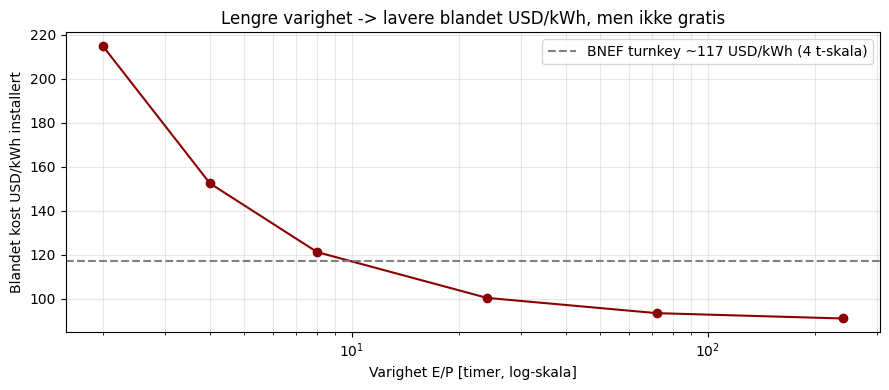

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df["duration_h"], df["blended_USD_per_kWh"], marker="o", color="darkred")
ax.axhline(defaults["turnkey_bess_cost_usd_per_kwh"], linestyle="--", color="grey",
           label=f"BNEF turnkey ~{defaults['turnkey_bess_cost_usd_per_kwh']:.0f} USD/kWh (4 t-skala)")
ax.set_xscale("log")
ax.set_xlabel("Varighet E/P [timer, log-skala]")
ax.set_ylabel("Blandet kost USD/kWh installert")
ax.set_title("Lengre varighet → lavere blandet USD/kWh, men ikke gratis")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Læring

- For **korte varigheter** dominerer effekt-kostnader. Det er derfor 1–2-timers BESS er dyre per kWh.
- For **lange varigheter** (Dunkelflaute) konvergerer USD/kWh nedover mot ren cellekost — men man bygger samtidig **enorme** energimengder.
- Hovednotebookens enkle USD/kWh-tall undervurderer effekt-siden for korte BESS, og overvurderer den (litt) for ekstremt lange varigheter. For systemstudier bør effekt og energi alltid skilles.
- Reell systemoptimalisering vil **velge** $E/P$ per teknologi: batteri på timer, hydrogen/CCGT på flere døgn.
